## IMPORTING LIBRARY

In [1]:
import pandas as pd

## LOAD DATASET

In [2]:
df = pd.read_csv("D:/STUDY MATERIAL/PROJECTS/DATA ANALYST/DATA/customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## DATASET OVERVIEW

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [4]:
df.describe(include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(lambda x:x.fillna(x.median()))

In [7]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns = {"purchase_amount_(usd)":"purchase_amount"})

# FEATURE ENGINEERING

## Create a Column age_group

In [8]:
labels = ["Young Adult","Adult","Middle Age","Senior"]
df["age_group"] = pd.qcut(df["age"],q=4, labels = labels)

In [9]:
df[["age", "age_group"]].head(10)

,age,age_group
0,55,Middle Age
1,19,Young Adult
2,50,Middle Age
3,21,Young Adult
4,45,Middle Age
5,46,Middle Age
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle Age


## Create a Column purchase_frequency_days

In [10]:
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df["purchase_frequency_days"] = df["frequency_of_purchases"].map(frequency_mapping)

In [11]:
df[["purchase_frequency_days","frequency_of_purchases"]].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


## Removing Unnecessary Columns

In [12]:
df[["discount_applied","promo_code_used"]].head(5)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [13]:
(df["discount_applied"] == df["promo_code_used"]).all()

np.True_

In [14]:
df = df.drop("promo_code_used", axis = 1)

In [15]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

# Purchase Distribution

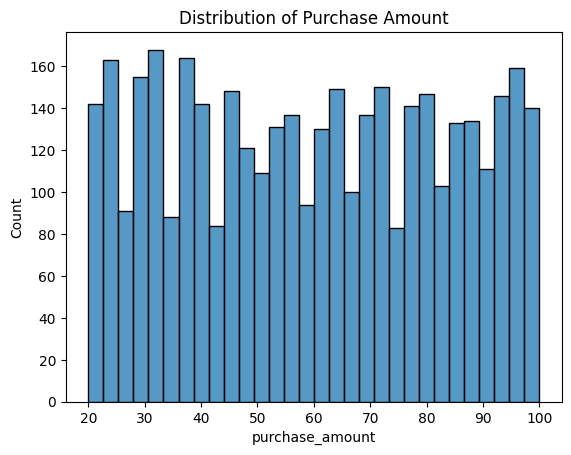

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["purchase_amount"], bins=30)
plt.title("Distribution of Purchase Amount")
plt.show()

# Category Popularity

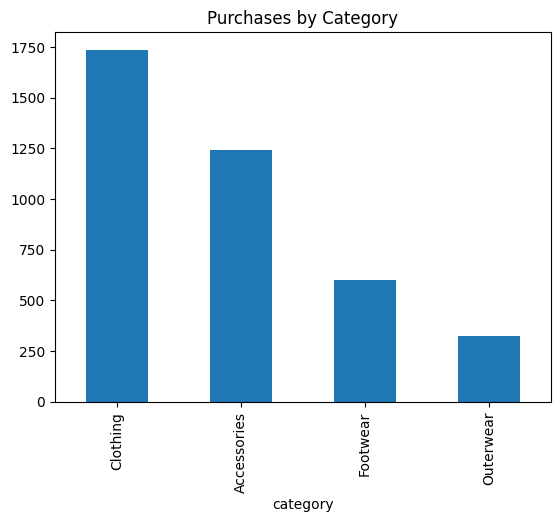

In [19]:
df["category"].value_counts().plot(kind="bar")
plt.title("Purchases by Category")
plt.show()

# Age vs Spending

<Axes: xlabel='age_group', ylabel='purchase_amount'>

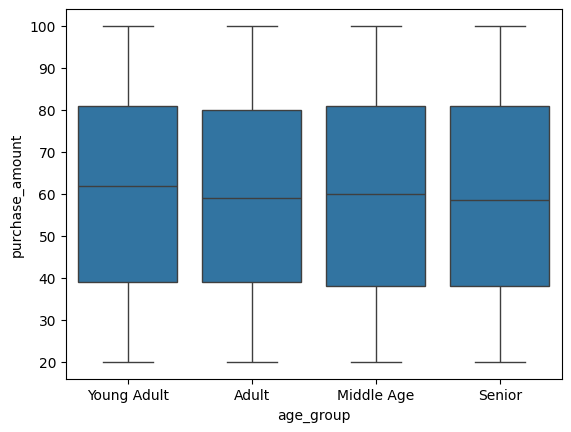

In [20]:
sns.boxplot(x="age_group", y="purchase_amount", data=df)

# Correlation Analysis

<Axes: >

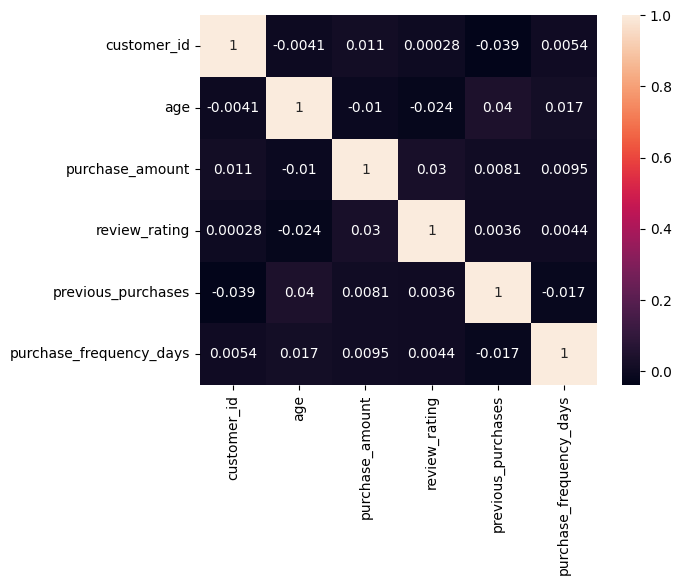

In [21]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

# Repeat Customer Behavior

In [22]:
df.groupby("previous_purchases")["purchase_amount"].mean()

previous_purchases
1     58.469880
2     60.333333
3     58.560440
4     61.274725
5     64.252874
6     55.850575
7     61.200000
8     66.671642
9     63.784615
10    58.184211
11    59.500000
12    59.253165
13    55.884058
14    57.967391
15    55.863014
16    62.157143
17    61.462687
18    59.142857
19    57.474359
20    61.891566
21    57.979167
22    54.753846
23    57.904110
24    60.197802
25    61.278481
26    58.870130
27    57.756410
28    61.887500
29    59.739130
30    59.353659
31    57.288660
32    61.530864
33    61.987805
34    54.050633
35    59.269841
36    62.239437
37    60.512821
38    65.142857
39    57.061728
40    54.207317
41    60.757143
42    58.855422
43    61.687500
44    61.291667
45    57.566265
46    59.589744
47    62.655556
48    63.588889
49    56.500000
50    65.272727
Name: purchase_amount, dtype: float64

# CONNECTING DATABSE

In [16]:
!pip install pymysql sqlalchemy cryptography


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
from sqlalchemy import create_engine

# Database credentials
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "mydatabase"  # Ensure this matches what you created in SQL

# The connection string
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Load your data
table_name = "customer_data"
try:
    df.to_sql(table_name, engine, if_exists="replace", index=False)
    print(f"Success! Data loaded into table '{table_name}' in database '{database}'.")
except Exception as e:
    print(f"Error: {e}")

# Verify by reading the first 5 rows
pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5;", engine)

Success! Data loaded into table 'customer_data' in database 'mydatabase'.


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle Age,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle Age,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle Age,365
